## Imports

In [1]:
import wandb
import logging
from tqdm import tqdm
from wandb.sdk.wandb_run import Run
import numpy as np
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.graph_objs as go
import seaborn as sns
import matplotlib.pyplot as plt
from nn_core.common import PROJECT_ROOT
import json

/media/donato/Extra-storage/Code/model-merging/mass/.venv/lib/python3.11/site-packages/lightning_utilities/core/imports.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/media/donato/Extra-storage/Code/model-merging/mass/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/donato/Extra-storage/Code/model-merging/mass/.venv/lib/python3.11/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Configuration

In [2]:
from mass.utils.plots import Palette

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "axes.titlesize": 24,        # Larger axes/title fonts
        "axes.labelsize": 24,
        "xtick.labelsize": 24,
        "ytick.labelsize": 20,
        "legend.fontsize": 24,
    }
)
sns.set_context("talk")

cmap_name = "coolwarm_r"

palette = Palette(f"{PROJECT_ROOT}/misc/palette.json", map_path=f"{PROJECT_ROOT}/misc/palette_map.json")
palette

Project not installed in the current env, activate the correct env or install it with:
	pip install -e .


{'blue': '#335c67',
 'white': '#fff3b0',
 'yellow': '#e09f3e',
 'red': '#9e2a2b',
 'dark red': '#540b0e',
 'green': '#81b29a'}

## Get runs

In [3]:
api = wandb.Api()
entity, project = "gladia", "mass"  # set to your entity and project

In [4]:
def get_runs(entity, project, positive_tags, negative_tags):
    filters_pos_tags = {"$and": [{"tags": {"$eq": pos_tag}} for pos_tag in positive_tags]}
    filters_neg_tags = {}

    print(filters_pos_tags)
    filters = {**filters_pos_tags, **filters_neg_tags}
    runs = api.runs(entity + "/" + project, filters=filters)

    print(f"There are {len(runs)} runs respecting these conditions.")
    return runs

In [5]:
tags = [
    "scaling",
]  

In [6]:
runs = get_runs(entity, project, positive_tags=tags, negative_tags=[])

{'$and': [{'tags': {'$eq': 'scaling'}}]}
There are 32 runs respecting these conditions.


In [7]:
print(set(runs[0].history().columns))

{'normalized_acc/test/SUN397', 'task_survival/CIFAR100', 'coefficients/PCAM', 'norms/Beans', 'coefficients_std/KMNIST_table', 'coefficients_std/STL10_table', 'task_survival/DTD', 'coefficients_std/EuroSAT_table', 'coefficients/IntelImages', 'coefficients/MangoLeafBD', 'task_survival/RESISC45', 'normalized_acc/test/PCAM', 'acc/test/FlowersKaggle', 'loss/test/Garbage', 'acc/test/avg', 'activated_tasks/RESISC45', 'task_accuracy/FashionMNIST', 'task_accuracy/SVHN', 'normalized_acc/test/GTSRB', 'task_accuracy/FER2013', 'norms/STL10', 'coefficients_std/CIFAR10_table', 'acc/test/CIFAR10', 'task_survival/RenderedSST2', 'task_accuracy/Dogs', 'task_survival/Cars', 'norms/KvasirV2', 'acc/test/EMNIST', 'task_accuracy/MNIST', 'task_survival/Flowers102', 'norms/OxfordIIITPet', 'coefficients_std/GTSRB_table', 'task_accuracy/IntelImages', 'coefficients/SUN397', 'coefficients/Flowers102', 'loss/test/Flowers102', 'normalized_acc/test/RenderedSST2', 'task_survival/Fruits360', 'acc/test/Weather', 'normali

In [8]:
models = ['ViT-B-32', 'ViT-B-16', 'ViT-L-14'] # ['ViT-B-32', 'ViT-B-16', 'ViT-L-14']
datasets =  ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'RESISC45', 'SUN397', 'SVHN', 'CIFAR100', 'STL10', 'Flowers102', 'OxfordIIITPet', 'PCAM', 'FER2013', 'EMNIST', 'CIFAR10', 'Food101', 'FashionMNIST', 'RenderedSST2', 'KMNIST', 'Beans', 'CUB200', 'Dogs', 'FlowersKaggle', 'Fruits360', 'Garbage', 'IntelImages', 'KenyanFood13', 'KvasirV2', 'Landscape', 'MangoLeafBD', 'Vegetables', 'Weather']

In [9]:
accs = {model: {dataset: None for dataset in datasets} for model in models}

#### Hparams

In [10]:
run_by_num_tasks = {i: 0.0 for i in range(2, 33)}


for run in runs:
    for model in models:

        # if the run failed or was killed, skip 
        if run.state in ['crashed', 'killed', 'running']:
            continue
        
        # runs are tagged with 'B32', 'B16', 'L14'
        if model not in run.tags:
            continue 
            
        cols = run.history().columns
        # Quirk: config wasn't uploaded when finetuned 
        num_tasks = len(run.config['eval_datasets'])

        remove_nans = lambda l : [x for x in l if not (isinstance(x, float) and np.isnan(x))]
        run_by_num_tasks[num_tasks] = remove_nans(run.history()['normalized_acc/test/avg'].values)[0]


In [11]:
run_by_num_tasks

{2: 0.9988402724266052,
 3: 0.9819466869036356,
 4: 0.9438698142766953,
 5: 0.9556779861450195,
 6: 0.9554549157619476,
 7: 0.9587698749133519,
 8: 0.9654170125722885,
 9: 0.9649663501315646,
 10: 0.9619836330413818,
 11: 0.9614470113407482,
 12: 0.9663590540488561,
 13: 0.9444039051349347,
 14: 0.9322612455912999,
 15: 0.9180340488751729,
 16: 0.9231878817081451,
 17: 0.9162790740237516,
 18: 0.9180033339394463,
 19: 0.9061461436121088,
 20: 0.9090058892965317,
 21: 0.9128990599087307,
 22: 0.9047557440671053,
 23: 0.8828507169433262,
 24: 0.8666809648275375,
 25: 0.8519403409957885,
 26: 0.8512055254899539,
 27: 0.838436347466928,
 28: 0.8293071814945766,
 29: 0.8280209878395344,
 30: 0.825455583135287,
 31: 0.8306052088737488,
 32: 0.83391825389117,
 33: 0.8261613511677944}

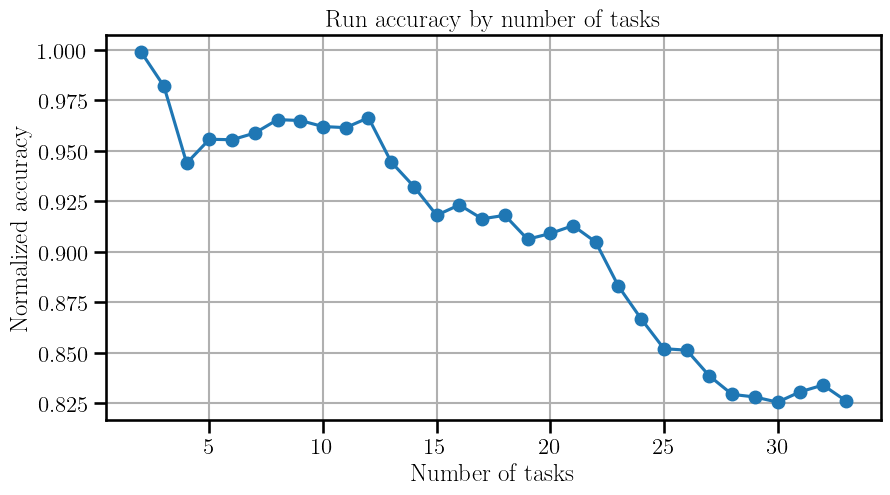

In [12]:
sorted_items = sorted(run_by_num_tasks.items())
xs, ys = zip(*sorted_items) if sorted_items else ([], [])
plt.figure(figsize=(10, 5))
plt.plot(xs, ys, marker='o')
plt.xlabel('Number of tasks')
plt.ylabel('Normalized accuracy')
plt.title('Run accuracy by number of tasks')
plt.grid(True)
plt.show()